In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


# Hotel Booking Cancellation Prediction

## 1. Data Understanding and Exploratory Data Analysis

This notebook performs the initial data understanding and exploratory data analysis (EDA) of the Hotel Booking dataset. The purpose is to understand the dataset structure, variable types, distributions, cancellation patterns, and potential data quality issues before preprocessing and model development.

### 1.2 Load the Dataset

The approved Hotel Booking dataset is loaded from the raw data directory. The original dataset will remain unchanged throughout the exploratory analysis.

In [2]:
df = pd.read_csv("../data/raw/hotel_booking.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


### 1.3 Initial Dataset Preview

The first five records are displayed to obtain an initial understanding of the dataset structure and the values contained within each feature.

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


### 1.4 Dataset Dimensions

The number of observations and attributes in the dataset is examined to understand its overall size.

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 119390
Number of columns: 36


### 1.5 Dataset Features

The following attributes are available in the dataset.

In [5]:
print("Column Names:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Column Names:

1. hotel
2. is_canceled
3. lead_time
4. arrival_date_year
5. arrival_date_month
6. arrival_date_week_number
7. arrival_date_day_of_month
8. stays_in_weekend_nights
9. stays_in_week_nights
10. adults
11. children
12. babies
13. meal
14. country
15. market_segment
16. distribution_channel
17. is_repeated_guest
18. previous_cancellations
19. previous_bookings_not_canceled
20. reserved_room_type
21. assigned_room_type
22. booking_changes
23. deposit_type
24. agent
25. company
26. days_in_waiting_list
27. customer_type
28. adr
29. required_car_parking_spaces
30. total_of_special_requests
31. reservation_status
32. reservation_status_date
33. name
34. email
35. phone-number
36. credit_card


### 1.6 Dataset Information and Data Types

The dataset structure is inspected to identify numerical, categorical, and other data types, as well as the number of non-null observations in each attribute.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### 1.7 Numerical and Categorical Feature Identification

The dataset contains a combination of numerical and categorical attributes. Identifying these variable types is important because different feature types may require different preprocessing and analysis techniques during later stages of the project.

In [7]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Number of numerical columns:", len(numerical_cols))
print("Numerical columns:")
print(numerical_cols)

print("\nNumber of categorical columns:", len(categorical_cols))
print("Categorical columns:")
print(categorical_cols)

Number of numerical columns: 20
Numerical columns:
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Number of categorical columns: 16
Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date', 'name', 'email', 'phone-number', 'credit_card']


### 1.8 Descriptive Statistics of Numerical Features

Descriptive statistics are examined to understand the central tendency, variability, and range of the numerical attributes. This analysis can also provide an initial indication of unusual values that may require further investigation during the data quality analysis stage.

In [8]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


### 1.9 Summary of Categorical Features

Categorical attributes are summarized to understand the number of unique categories, the most frequently occurring category, and its frequency. This provides an initial understanding of the composition of the categorical variables.

In [9]:
df[categorical_cols].describe().T

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


### 1.10 Target Variable Analysis

The target variable of this project is `is_canceled`, where 0 represents a booking that was not cancelled and 1 represents a cancelled booking. The distribution of the target variable is examined to understand the proportion of cancelled and non-cancelled reservations and to identify any potential class imbalance.

In [10]:
target_counts = df["is_canceled"].value_counts().sort_index()

print("Target Variable Counts:")
print(target_counts)

Target Variable Counts:
is_canceled
0    75166
1    44224
Name: count, dtype: int64


In [11]:
target_percentages = (
    df["is_canceled"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print("Target Variable Percentages:")
print(target_percentages.round(2))

Target Variable Percentages:
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


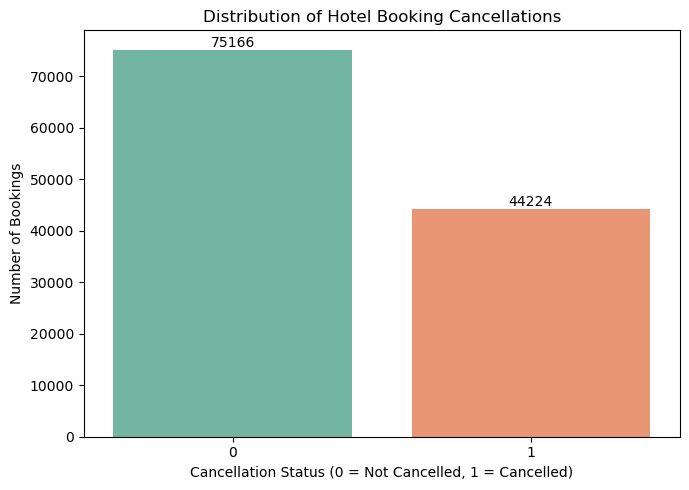

In [12]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="is_canceled",
    hue="is_canceled",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Hotel Booking Cancellations")
plt.xlabel("Cancellation Status (0 = Not Cancelled, 1 = Cancelled)")
plt.ylabel("Number of Bookings")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

#### Observation

The target variable `is_canceled` contains two classes representing the final booking status:

- **75,166 bookings (62.96%)** were not cancelled (`is_canceled = 0`).
- **44,224 bookings (37.04%)** were cancelled (`is_canceled = 1`).

The results show that non-cancelled bookings form the majority class, while cancelled bookings account for a substantial proportion of the dataset. Therefore, the target variable is moderately imbalanced rather than perfectly balanced.

Because both classes contain a large number of observations, the dataset provides sufficient examples of both cancelled and non-cancelled bookings for model development. However, the observed class distribution should be considered during model evaluation. In addition to accuracy, metrics such as precision, recall, F1-score, ROC-AUC, and the confusion matrix will be considered when comparing classification models.

#### 1.11 Cancellation Analysis by Hotel Type

In [13]:
hotel_cancellation = pd.crosstab(
    df["hotel"],
    df["is_canceled"],
    normalize="index"
).mul(100)

hotel_cancellation.columns = ["Not Cancelled (%)", "Cancelled (%)"]

hotel_cancellation.round(2)

,Not Cancelled (%),Cancelled (%)
hotel,,
City Hotel,58.27,41.73
Resort Hotel,72.24,27.76


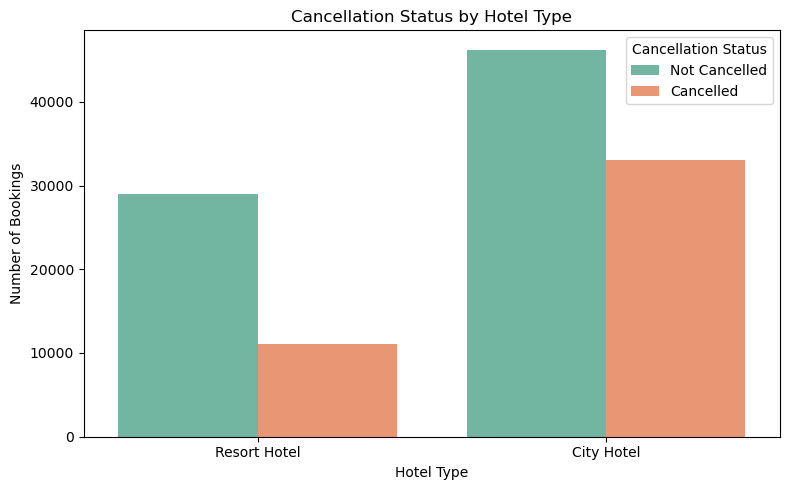

In [14]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="hotel",
    hue="is_canceled",
    palette="Set2"
)

plt.title("Cancellation Status by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")

plt.legend(
    title="Cancellation Status",
    labels=["Not Cancelled", "Cancelled"]
)

plt.tight_layout()
plt.show()

#### Observation

The analysis shows a noticeable difference in cancellation behaviour between the two hotel types.

- **City Hotel:** 58.27% of bookings were not cancelled, while **41.73% were cancelled**.
- **Resort Hotel:** 72.24% of bookings were not cancelled, while **27.76% were cancelled**.
- The cancellation rate for City Hotel bookings is approximately **13.97 percentage points higher** than that of Resort Hotel bookings.
- This suggests that hotel type may provide useful predictive information for cancellation prediction. However, this observed association does not imply that the hotel type itself causes cancellations.

### 1.12 Lead Time and Booking Cancellation Analysis

Lead time represents the number of days between the date a booking is made and the expected arrival date. This analysis investigates whether the distribution of lead time differs between cancelled and non-cancelled bookings and whether lead time may contain useful predictive information for booking cancellation.

In [15]:
lead_time_stats = df.groupby("is_canceled")["lead_time"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

lead_time_stats.index = ["Not Cancelled", "Cancelled"]

lead_time_stats

,count,mean,median,std,min,max
Not Cancelled,75166,79.98,45.0,91.11,0,737
Cancelled,44224,144.85,113.0,118.62,0,629


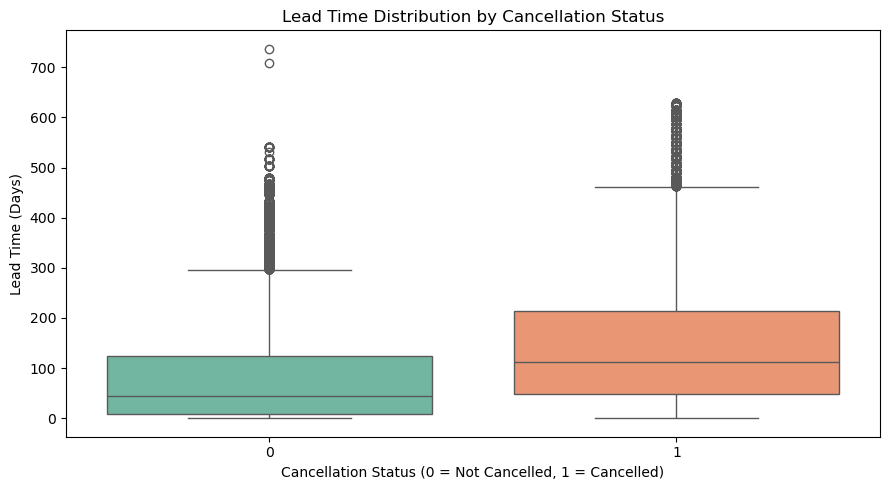

In [16]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="is_canceled",
    y="lead_time",
    hue="is_canceled",
    palette="Set2",
    legend=False
)

plt.title("Lead Time Distribution by Cancellation Status")
plt.xlabel("Cancellation Status (0 = Not Cancelled, 1 = Cancelled)")
plt.ylabel("Lead Time (Days)")

plt.tight_layout()
plt.show()

In [17]:
lead_time_bins = pd.cut(
    df["lead_time"],
    bins=[-1, 7, 30, 90, 180, 365, float("inf")],
    labels=[
        "0-7 days",
        "8-30 days",
        "31-90 days",
        "91-180 days",
        "181-365 days",
        "365+ days"
    ]
)

lead_time_cancellation_rate = (
    df.assign(lead_time_group=lead_time_bins)
      .groupby("lead_time_group", observed=False)["is_canceled"]
      .mean()
      .mul(100)
      .round(2)
)

lead_time_cancellation_rate

lead_time_group
0-7 days         9.63
8-30 days       27.86
31-90 days      37.70
91-180 days     44.71
181-365 days    55.45
365+ days       67.66
Name: is_canceled, dtype: float64

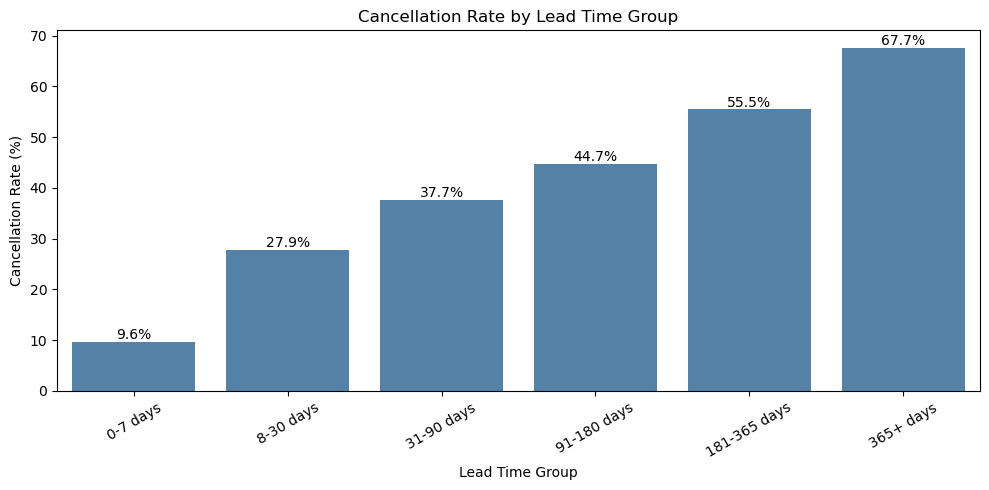

In [18]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=lead_time_cancellation_rate.index,
    y=lead_time_cancellation_rate.values,
    color="steelblue"
)

plt.title("Cancellation Rate by Lead Time Group")
plt.xlabel("Lead Time Group")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=30)

for i, value in enumerate(lead_time_cancellation_rate.values):
    ax.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

#### Observation

The analysis indicates a clear relationship between lead time and booking cancellation behaviour.

- Non-cancelled bookings have an average lead time of **79.98 days** and a median lead time of **45 days**.
- Cancelled bookings have a considerably higher average lead time of **144.85 days** and a median lead time of **113 days**.
- The cancellation rate increases progressively across the selected lead-time groups:
  - **0-7 days:** 9.63%
  - **8-30 days:** 27.86%
  - **31-90 days:** 37.70%
  - **91-180 days:** 44.71%
  - **181-365 days:** 55.45%
  - **365+ days:** 67.66%
- The boxplot also shows that the lead-time distribution for cancelled bookings is generally higher than that of non-cancelled bookings.
- Several unusually high lead-time observations are visible in the distribution. These observations should be investigated during the data-quality and outlier analysis stage rather than removed at this stage.

Overall, the results show that bookings made further in advance are associated with a higher cancellation rate in this dataset. Therefore, `lead_time` appears to be a potentially informative feature for predicting booking cancellations. However, this analysis demonstrates an association and does not establish that a longer lead time directly causes a customer to cancel a booking.

### 1.13 Deposit Type and Booking Cancellation Analysis

Deposit type indicates the deposit policy associated with each hotel booking. This analysis investigates whether booking cancellation behaviour differs across the available deposit categories. Both the distribution of bookings and the cancellation rate within each deposit type are examined to determine whether `deposit_type` may provide useful predictive information.

In [19]:
deposit_counts = df["deposit_type"].value_counts()

deposit_percentages = (
    df["deposit_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

deposit_summary = pd.DataFrame({
    "Booking Count": deposit_counts,
    "Percentage (%)": deposit_percentages
})

deposit_summary

,Booking Count,Percentage (%)
deposit_type,,
No Deposit,104641,87.65
Non Refund,14587,12.22
Refundable,162,0.14


In [20]:
deposit_cancellation = pd.crosstab(
    df["deposit_type"],
    df["is_canceled"],
    normalize="index"
).mul(100)

deposit_cancellation.columns = [
    "Not Cancelled (%)",
    "Cancelled (%)"
]

deposit_cancellation.round(2)

,Not Cancelled (%),Cancelled (%)
deposit_type,,
No Deposit,71.62,28.38
Non Refund,0.64,99.36
Refundable,77.78,22.22


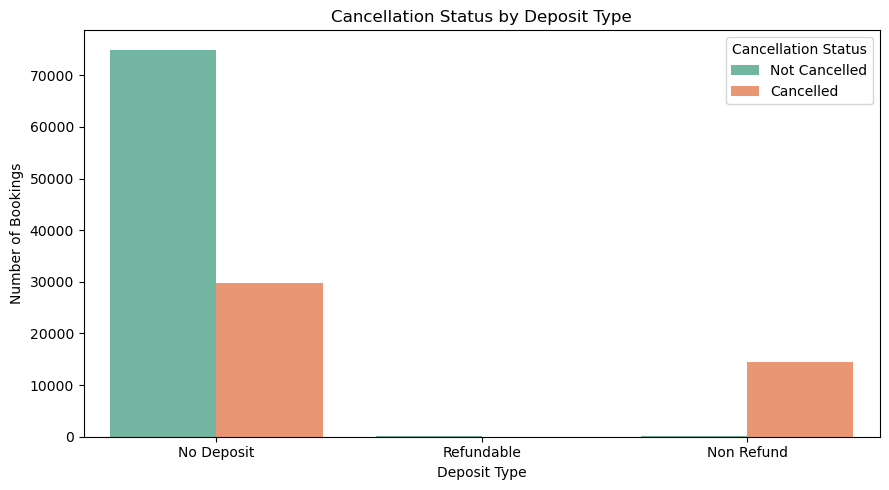

In [21]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="deposit_type",
    hue="is_canceled",
    palette="Set2"
)

plt.title("Cancellation Status by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Number of Bookings")

plt.legend(
    title="Cancellation Status",
    labels=["Not Cancelled", "Cancelled"]
)

plt.tight_layout()
plt.show()

In [22]:
deposit_cancellation_rate = (
    df.groupby("deposit_type")["is_canceled"]
    .mean()
    .mul(100)
    .sort_values()
    .round(2)
)

deposit_cancellation_rate

deposit_type
Refundable    22.22
No Deposit    28.38
Non Refund    99.36
Name: is_canceled, dtype: float64

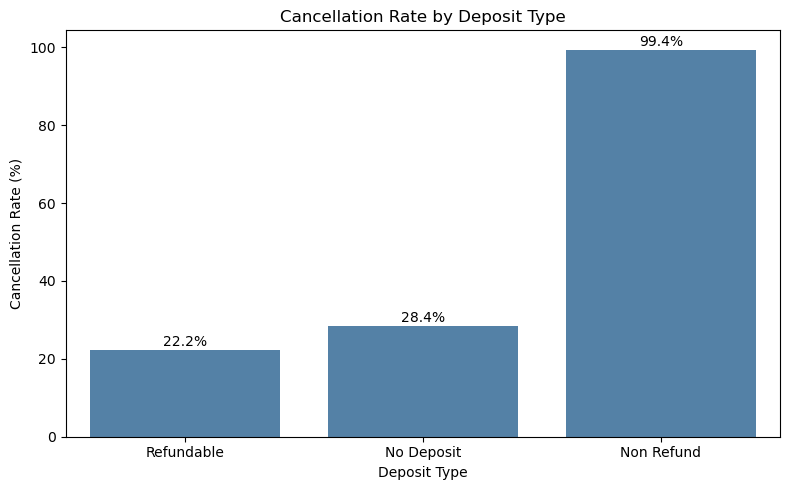

In [23]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=deposit_cancellation_rate.index,
    y=deposit_cancellation_rate.values,
    color="steelblue"
)

plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate (%)")

for i, value in enumerate(deposit_cancellation_rate.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

#### Observation

The analysis reveals substantial differences in booking cancellation behaviour across the three deposit types.

- **No Deposit** is the dominant category, representing **104,641 bookings (87.65%)** of the dataset. Among these bookings, **28.38% were cancelled** and 71.62% were not cancelled.
- **Non Refund** represents **14,587 bookings (12.22%)** of the dataset. This category shows a remarkably high cancellation rate of **99.36%**, with only 0.64% of bookings not cancelled.
- **Refundable** is a very small category, containing only **162 bookings (0.14%)** of the dataset. Its observed cancellation rate is **22.22%**, while 77.78% of bookings were not cancelled.

The results indicate a strong association between `deposit_type` and booking cancellation behaviour, particularly for the `Non Refund` category. Therefore, `deposit_type` may provide useful predictive information for the cancellation prediction model.

However, the unusually high cancellation rate observed for `Non Refund` bookings should be investigated further together with other booking characteristics before drawing a causal conclusion. Additionally, the `Refundable` category contains very few observations compared with the other categories, so its cancellation percentage should be interpreted with caution.

At this stage, no categories will be removed or modified. Any treatment decisions will be made during the data preprocessing stage after further investigation.

### 1.14 Market Segment and Booking Cancellation Analysis

The `market_segment` variable represents the market segment through which a hotel booking was made. This analysis examines the distribution of bookings across different market segments and compares their cancellation behaviour. The objective is to determine whether the booking market segment may provide useful information for predicting hotel booking cancellations.

In [24]:
market_counts = df["market_segment"].value_counts()

market_percentages = (
    df["market_segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

market_summary = pd.DataFrame({
    "Booking Count": market_counts,
    "Percentage (%)": market_percentages
})

market_summary

,Booking Count,Percentage (%)
market_segment,,
Online TA,56477,47.30
Offline TA/TO,24219,20.29
Groups,19811,16.59
Direct,12606,10.56
Corporate,5295,4.44
Complementary,743,0.62
Aviation,237,0.20
Undefined,2,0.00


In [25]:
market_cancellation = pd.crosstab(
    df["market_segment"],
    df["is_canceled"],
    normalize="index"
).mul(100)

market_cancellation.columns = [
    "Not Cancelled (%)",
    "Cancelled (%)"
]

market_cancellation.round(2)

,Not Cancelled (%),Cancelled (%)
market_segment,,
Aviation,78.06,21.94
Complementary,86.94,13.06
Corporate,81.27,18.73
Direct,84.66,15.34
Groups,38.94,61.06
Offline TA/TO,65.68,34.32
Online TA,63.28,36.72
Undefined,0.00,100.00


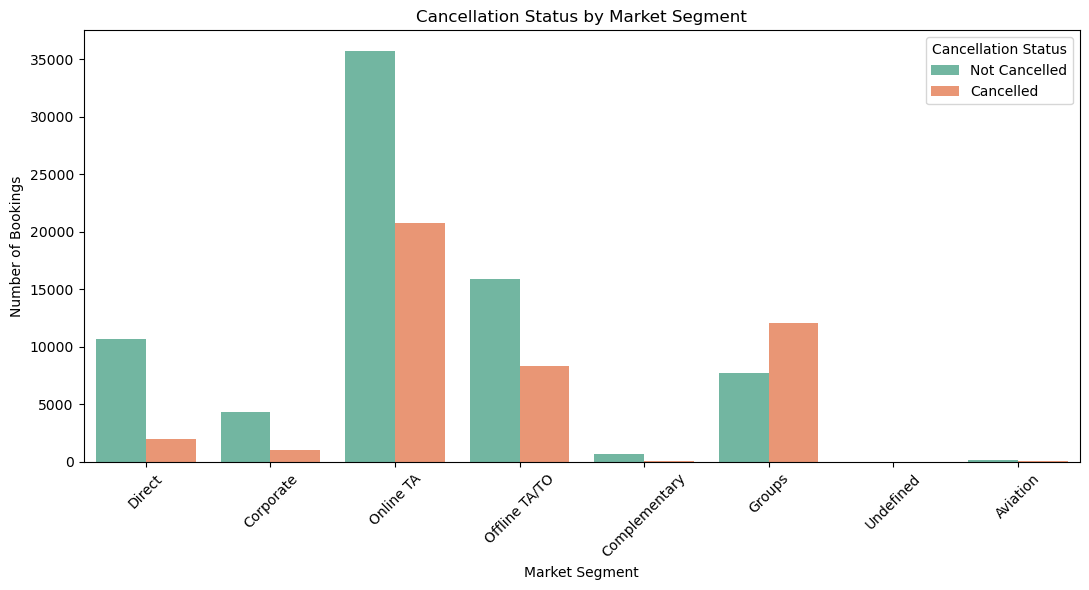

In [26]:
plt.figure(figsize=(11, 6))

sns.countplot(
    data=df,
    x="market_segment",
    hue="is_canceled",
    palette="Set2"
)

plt.title("Cancellation Status by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=45)

plt.legend(
    title="Cancellation Status",
    labels=["Not Cancelled", "Cancelled"]
)

plt.tight_layout()
plt.show()

In [27]:
market_cancellation_rate = (
    df.groupby("market_segment")["is_canceled"]
    .mean()
    .mul(100)
    .sort_values()
    .round(2)
)

market_cancellation_rate

market_segment
Complementary     13.06
Direct            15.34
Corporate         18.73
Aviation          21.94
Offline TA/TO     34.32
Online TA         36.72
Groups            61.06
Undefined        100.00
Name: is_canceled, dtype: float64

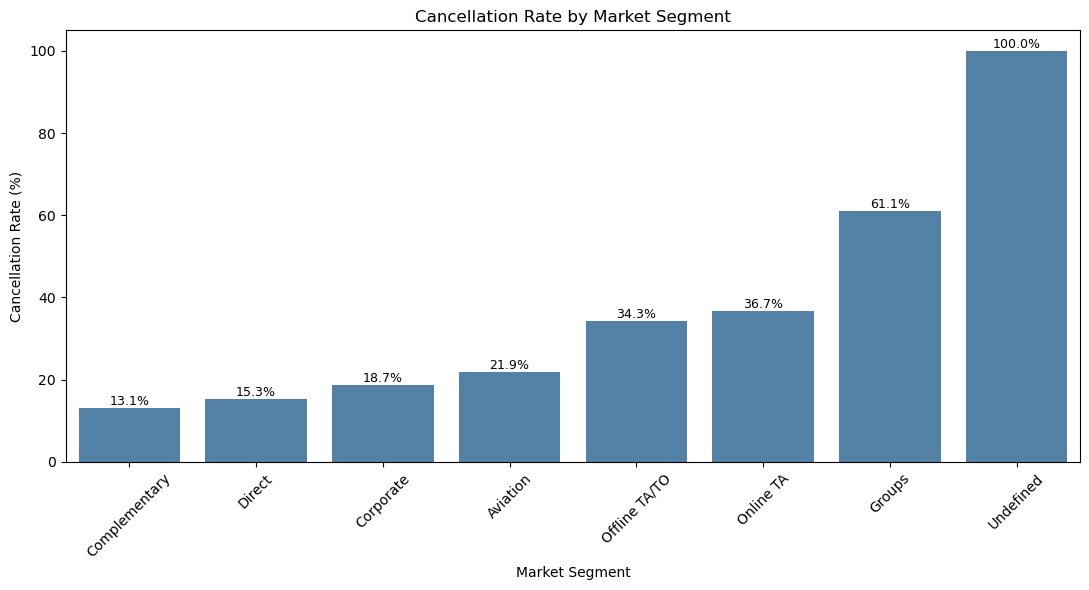

In [28]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=market_cancellation_rate.index,
    y=market_cancellation_rate.values,
    color="steelblue"
)

plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Cancellation Rate (%)")

plt.xticks(rotation=45)

for i, value in enumerate(market_cancellation_rate.values):
    ax.text(
        i,
        value + 0.7,
        f"{value:.1f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### Observation

The analysis shows that booking cancellation behaviour varies considerably across different market segments.

- **Online TA** is the largest market segment with **56,477 bookings (47.30%)**, and it has a cancellation rate of **36.72%**.
- **Offline TA/TO** represents **24,219 bookings (20.29%)**, with a cancellation rate of **34.32%**.
- **Groups** represents **19,811 bookings (16.59%)** and records the highest meaningful cancellation rate among the major market segments at **61.06%**.
- **Direct** bookings account for **12,606 bookings (10.56%)** and show a comparatively lower cancellation rate of **15.34%**.
- **Corporate** bookings represent **5,295 bookings (4.44%)**, with a cancellation rate of **18.73%**.
- The smaller **Complementary** and **Aviation** segments show cancellation rates of **13.06%** and **21.94%**, respectively.
- Although the **Undefined** category shows a cancellation rate of **100%**, this category contains only **2 bookings**. Therefore, this percentage is not considered sufficient evidence of a general cancellation pattern and should be interpreted with caution.

Overall, the results indicate that `market_segment` is associated with different cancellation patterns. In particular, the relatively high cancellation rate observed for the `Groups` segment and the substantial number of cancelled bookings within the `Online TA` segment suggest that market segment may provide useful predictive information for the machine learning models.

However, these findings represent associations within the dataset and do not establish that the market segment itself causes booking cancellations. Small categories should also be carefully considered during later preprocessing and modelling stages.

### 1.15 Previous Cancellations and Current Booking Cancellation Analysis

The `previous_cancellations` variable represents the number of previous bookings cancelled by a customer before the current booking. This analysis investigates whether customers with a history of previous cancellations demonstrate different cancellation behaviour for their current booking.

The distribution of previous cancellation history and the corresponding cancellation rates are examined to determine whether this feature may provide useful predictive information.

In [29]:
previous_cancel_summary = df["previous_cancellations"].describe()

previous_cancel_summary

count    119390.000000
mean          0.087118
std           0.844336
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          26.000000
Name: previous_cancellations, dtype: float64

In [30]:
previous_cancel_counts = (
    df["previous_cancellations"]
    .value_counts()
    .sort_index()
)

previous_cancel_counts

previous_cancellations
0     112906
1       6051
2        116
3         65
4         31
5         19
6         22
11        35
13        12
14        14
19        19
21         1
24        48
25        25
26        26
Name: count, dtype: int64

In [31]:
previous_cancel_stats = (
    df.groupby("is_canceled")["previous_cancellations"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

previous_cancel_stats.index = [
    "Not Cancelled",
    "Cancelled"
]

previous_cancel_stats

,count,mean,median,std,min,max
Not Cancelled,75166,0.02,0.0,0.27,0,13
Cancelled,44224,0.21,0.0,1.33,0,26


In [32]:
previous_cancel_group = pd.cut(
    df["previous_cancellations"],
    bins=[-1, 0, 1, 2, float("inf")],
    labels=[
        "0",
        "1",
        "2",
        "3+"
    ]
)

previous_cancel_group_counts = (
    previous_cancel_group
    .value_counts()
    .sort_index()
)

previous_cancel_group_counts

previous_cancellations
0     112906
1       6051
2        116
3+       317
Name: count, dtype: int64

In [33]:
previous_cancel_rate = (
    df.assign(previous_cancel_group=previous_cancel_group)
      .groupby(
          "previous_cancel_group",
          observed=False
      )["is_canceled"]
      .agg(["count", "mean"])
)

previous_cancel_rate["Cancellation Rate (%)"] = (
    previous_cancel_rate["mean"] * 100
).round(2)

previous_cancel_rate = previous_cancel_rate[
    ["count", "Cancellation Rate (%)"]
]

previous_cancel_rate

,count,Cancellation Rate (%)
previous_cancel_group,,
0,112906,33.91
1,6051,94.43
2,116,32.76
3+,317,59.94


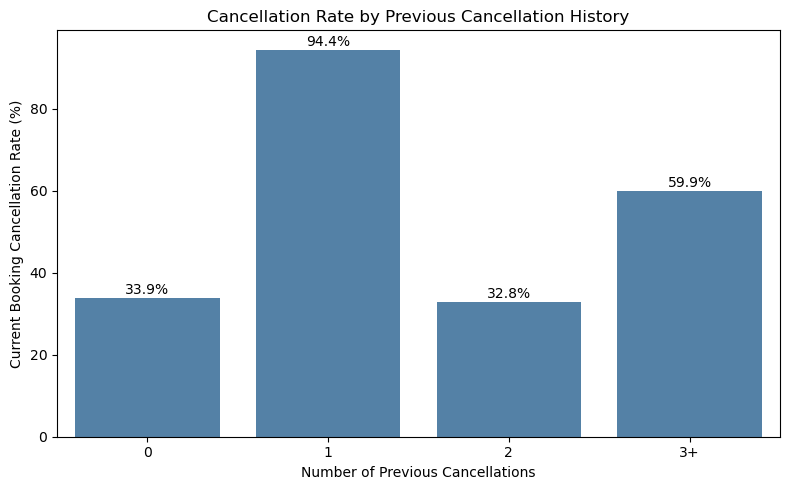

In [34]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=previous_cancel_rate.index,
    y=previous_cancel_rate["Cancellation Rate (%)"],
    color="steelblue"
)

plt.title("Cancellation Rate by Previous Cancellation History")
plt.xlabel("Number of Previous Cancellations")
plt.ylabel("Current Booking Cancellation Rate (%)")

for i, value in enumerate(
    previous_cancel_rate["Cancellation Rate (%)"]
):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

#### Observation

The analysis shows that previous cancellation history is associated with the cancellation status of the current booking, although the relationship is not strictly linear.

- The majority of bookings, **112,906 records**, belong to customers with no previous cancellations. These bookings have a current cancellation rate of **33.91%**.
- Customers with exactly **one previous cancellation** account for **6,051 bookings** and show a substantially higher current cancellation rate of **94.43%**.
- Customers with exactly **two previous cancellations** represent only **116 bookings** and have a cancellation rate of **32.76%**.
- Customers with **three or more previous cancellations** represent **317 bookings** and have a cancellation rate of **59.94%**.
- The mean number of previous cancellations is higher among currently cancelled bookings (**0.21**) than among non-cancelled bookings (**0.02**), while the median is **0** for both groups.

The results suggest that `previous_cancellations` may provide useful predictive information, particularly because customers with exactly one previous cancellation show a very high current cancellation rate. However, the relationship is not consistently increasing as the number of previous cancellations increases.

The categories containing two or more previous cancellations also contain relatively few observations compared with the zero and one-cancellation groups. Therefore, their cancellation percentages should be interpreted with caution.

At this stage, the feature will be retained for further investigation. No transformation, removal, or grouping decision will be finalized until the preprocessing and feature engineering stages.

### 1.16 Special Requests and Booking Cancellation Analysis

The `total_of_special_requests` variable represents the number of special requests associated with a booking. This analysis examines whether cancellation behaviour differs according to the number of special requests made by customers.

The distribution of special requests and the corresponding cancellation rates are analysed to determine whether this feature may contain useful predictive information for booking cancellation.

In [35]:
special_request_summary = (
    df["total_of_special_requests"]
    .value_counts()
    .sort_index()
)

special_request_summary

total_of_special_requests
0    70318
1    33226
2    12969
3     2497
4      340
5       40
Name: count, dtype: int64

In [36]:
special_request_rate = (
    df.groupby("total_of_special_requests")["is_canceled"]
    .agg(["count", "mean"])
)

special_request_rate["Cancellation Rate (%)"] = (
    special_request_rate["mean"] * 100
).round(2)

special_request_rate = special_request_rate[
    ["count", "Cancellation Rate (%)"]
]

special_request_rate

,count,Cancellation Rate (%)
total_of_special_requests,,
0,70318,47.72
1,33226,22.02
2,12969,22.10
3,2497,17.86
4,340,10.59
5,40,5.00


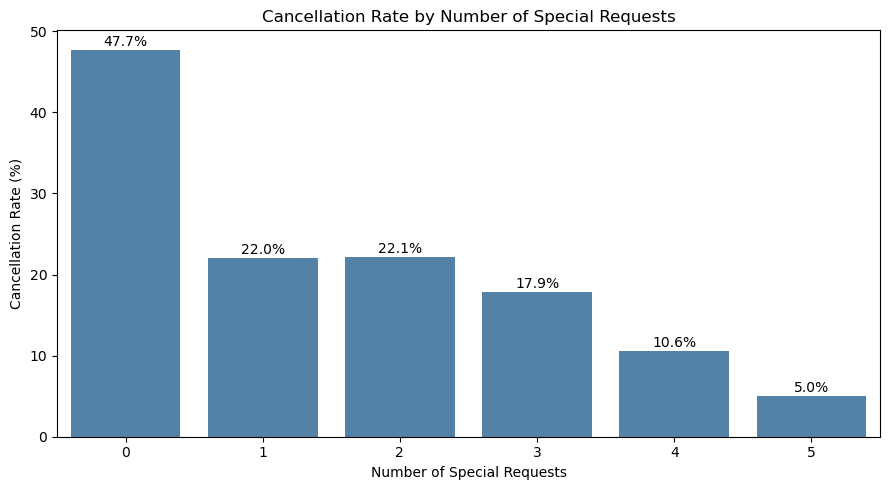

In [37]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=special_request_rate.index,
    y=special_request_rate["Cancellation Rate (%)"],
    color="steelblue"
)

plt.title("Cancellation Rate by Number of Special Requests")
plt.xlabel("Number of Special Requests")
plt.ylabel("Cancellation Rate (%)")

for i, value in enumerate(
    special_request_rate["Cancellation Rate (%)"]
):
    ax.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

#### Observation

The analysis shows a clear relationship between the number of special requests and booking cancellation behaviour.

- Bookings with **no special requests** form the largest group, with **70,318 bookings**, and show the highest cancellation rate of **47.72%**.
- Bookings with **one special request** account for **33,226 bookings** and have a considerably lower cancellation rate of **22.02%**.
- Bookings with **two special requests** represent **12,969 bookings**, with a cancellation rate of **22.10%**.
- For bookings with **three special requests**, the cancellation rate decreases further to **17.86%**.
- Bookings with **four special requests** have an observed cancellation rate of **10.59%**.
- Bookings with **five special requests** show the lowest cancellation rate of **5.00%**. However, this category contains only **40 bookings**, so this percentage should be interpreted with caution due to the very small sample size.

Overall, bookings with at least one special request show substantially lower cancellation rates than bookings with no special requests. The observed cancellation rate also generally decreases as the number of special requests increases, although the rates for one and two requests are very similar.

These findings suggest that `total_of_special_requests` may provide useful predictive information for the machine learning model. However, the analysis demonstrates an association rather than a causal relationship, and the very small sample sizes for the highest numbers of special requests should be considered during later modelling and evaluation.

### 1.17 Arrival Month and Booking Cancellation Analysis

The `arrival_date_month` variable represents the expected month of arrival for each hotel booking. This analysis examines the monthly distribution of reservations and investigates whether booking cancellation behaviour varies across different arrival months.

Both booking volume and cancellation rate are considered because a month with a large number of cancelled bookings may simply have a higher overall booking volume. Therefore, cancellation percentages are analysed to provide a more meaningful comparison between months.

In [38]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

In [39]:
monthly_counts = (
    df["arrival_date_month"]
    .value_counts()
    .reindex(month_order)
)

monthly_percentages = (
    df["arrival_date_month"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex(month_order)
    .round(2)
)

monthly_summary = pd.DataFrame({
    "Booking Count": monthly_counts,
    "Percentage (%)": monthly_percentages
})

monthly_summary

,Booking Count,Percentage (%)
arrival_date_month,,
January,5929,4.97
February,8068,6.76
March,9794,8.20
April,11089,9.29
May,11791,9.88
June,10939,9.16
July,12661,10.60
August,13877,11.62
September,10508,8.80


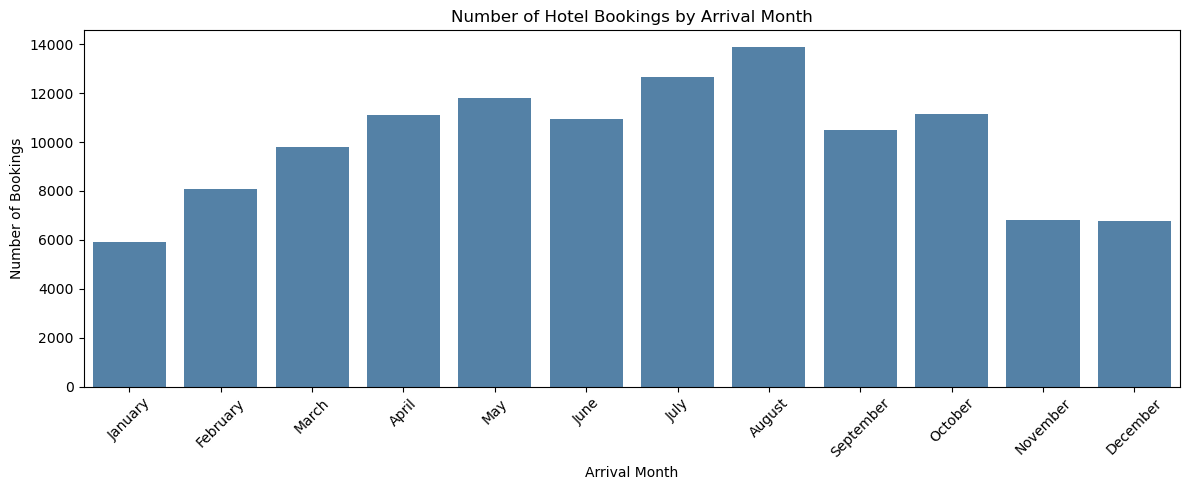

In [40]:
plt.figure(figsize=(12, 5))

ax = sns.barplot(
    x=monthly_summary.index,
    y=monthly_summary["Booking Count"],
    color="steelblue"
)

plt.title("Number of Hotel Bookings by Arrival Month")
plt.xlabel("Arrival Month")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [41]:
monthly_cancellation = (
    df.groupby("arrival_date_month")["is_canceled"]
    .agg(["count", "mean"])
    .reindex(month_order)
)

monthly_cancellation["Cancellation Rate (%)"] = (
    monthly_cancellation["mean"] * 100
).round(2)

monthly_cancellation = monthly_cancellation[
    ["count", "Cancellation Rate (%)"]
]

monthly_cancellation

,count,Cancellation Rate (%)
arrival_date_month,,
January,5929,30.48
February,8068,33.42
March,9794,32.15
April,11089,40.80
May,11791,39.67
June,10939,41.46
July,12661,37.45
August,13877,37.75
September,10508,39.17


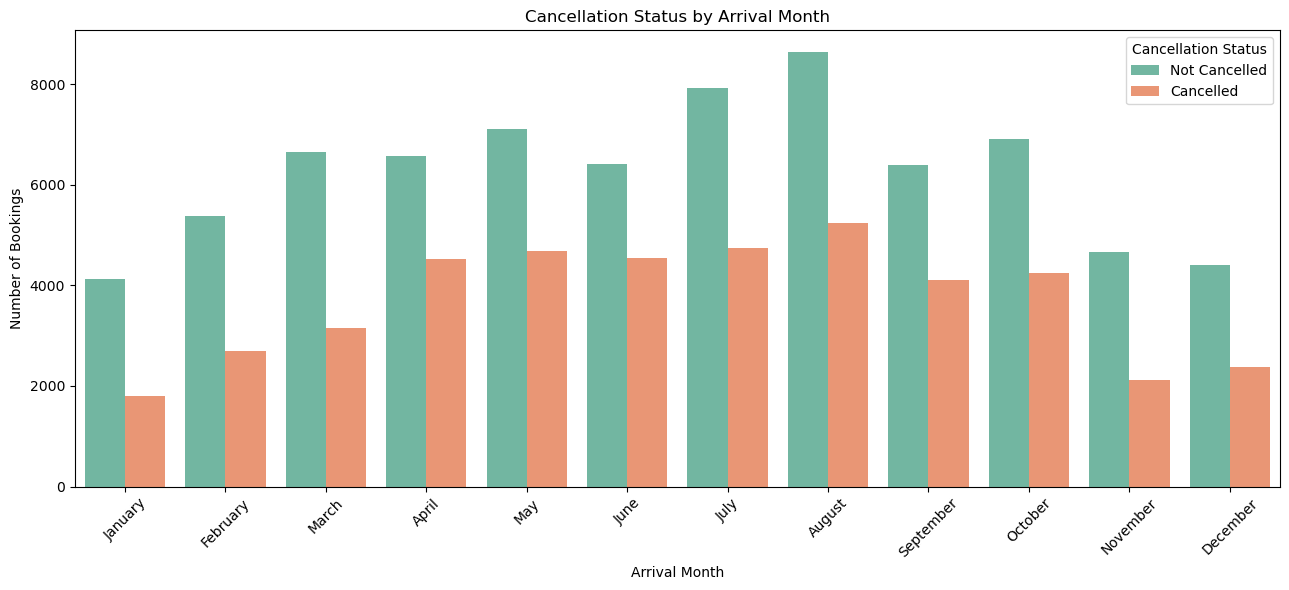

In [42]:
plt.figure(figsize=(13, 6))

sns.countplot(
    data=df,
    x="arrival_date_month",
    hue="is_canceled",
    order=month_order,
    palette="Set2"
)

plt.title("Cancellation Status by Arrival Month")
plt.xlabel("Arrival Month")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=45)

plt.legend(
    title="Cancellation Status",
    labels=["Not Cancelled", "Cancelled"]
)

plt.tight_layout()
plt.show()

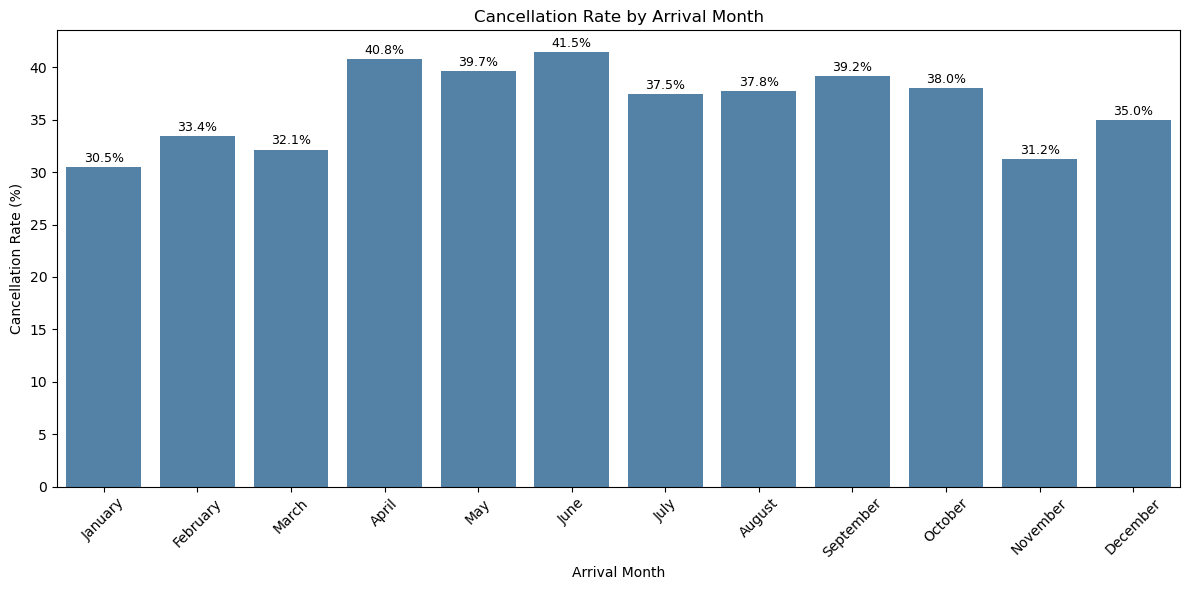

In [43]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=monthly_cancellation.index,
    y=monthly_cancellation["Cancellation Rate (%)"],
    color="steelblue"
)

plt.title("Cancellation Rate by Arrival Month")
plt.xlabel("Arrival Month")
plt.ylabel("Cancellation Rate (%)")

plt.xticks(rotation=45)

for i, value in enumerate(
    monthly_cancellation["Cancellation Rate (%)"]
):
    ax.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [44]:
highest_cancel_month = (
    monthly_cancellation["Cancellation Rate (%)"].idxmax()
)

highest_cancel_rate = (
    monthly_cancellation["Cancellation Rate (%)"].max()
)

lowest_cancel_month = (
    monthly_cancellation["Cancellation Rate (%)"].idxmin()
)

lowest_cancel_rate = (
    monthly_cancellation["Cancellation Rate (%)"].min()
)

print(
    f"Highest cancellation rate: "
    f"{highest_cancel_month} ({highest_cancel_rate:.2f}%)"
)

print(
    f"Lowest cancellation rate: "
    f"{lowest_cancel_month} ({lowest_cancel_rate:.2f}%)"
)

Highest cancellation rate: June (41.46%)
Lowest cancellation rate: January (30.48%)


In [ ]:
#### Observation

The analysis indicates that both hotel booking volume and cancellation behaviour vary across arrival months.

- **August** records the highest booking volume with **13,877 bookings (11.62%)**, while **January** records the lowest booking volume with **5,929 bookings (4.97%)**.
- Monthly cancellation rates vary from approximately **30.48% to 41.46%**, indicating noticeable seasonal differences in cancellation behaviour.
- **June** has the highest observed cancellation rate at **41.46%**, followed by **April (40.80%)** and **May (39.67%)**.
- **January** has the lowest observed cancellation rate at **30.48%**, followed by **November (31.23%)** and **March (32.15%)**.
- Although **August** has the highest number of bookings, its cancellation rate is **37.75%**, demonstrating that a high booking volume does not necessarily correspond to the highest cancellation rate.
- The monthly pattern suggests that `arrival_date_month` may contain useful information for predicting booking cancellations.

Overall, the results indicate an association between arrival month and booking cancellation behaviour. However, the observed monthly differences should not be interpreted as evidence that a particular month directly causes cancellations. Other factors such as hotel type, lead time, market segment, and booking characteristics may contribute to these patterns.


### 1.18 Initial Numerical Correlation Analysis

Correlation analysis is performed to obtain an initial understanding of the linear relationships among numerical variables in the dataset, with particular attention to their association with the target variable `is_canceled`.

This analysis can help identify numerical features that may contain useful predictive information and highlight strongly related variables that may require further investigation. However, correlation alone will not be used to determine feature importance or to remove variables, as weak linear correlation does not necessarily imply that a feature has no predictive value.

In [45]:
numerical_df = df.select_dtypes(include=np.number)

correlation_matrix = numerical_df.corr()

correlation_matrix.round(2)

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
is_canceled,1.00,0.29,0.02,0.01,-0.01,-0.00,0.02,0.06,0.01,-0.03,-0.08,0.11,-0.06,-0.14,-0.08,-0.02,0.05,0.05,-0.20,-0.23
lead_time,0.29,1.00,0.04,0.13,0.00,0.09,0.17,0.12,-0.04,-0.02,-0.12,0.09,-0.07,0.00,-0.07,0.15,0.17,-0.06,-0.12,-0.10
arrival_date_year,0.02,0.04,1.00,-0.54,-0.00,0.02,0.03,0.03,0.05,-0.01,0.01,-0.12,0.03,0.03,0.06,0.26,-0.06,0.20,-0.01,0.11
arrival_date_week_number,0.01,0.13,-0.54,1.00,0.07,0.02,0.02,0.03,0.01,0.01,-0.03,0.04,-0.02,0.01,-0.03,-0.08,0.02,0.08,0.00,0.03
arrival_date_day_of_month,-0.01,0.00,-0.00,0.07,1.00,-0.02,-0.03,-0.00,0.01,-0.00,-0.01,-0.03,-0.00,0.01,0.00,0.04,0.02,0.03,0.01,0.00
stays_in_weekend_nights,-0.00,0.09,0.02,0.02,-0.02,1.00,0.50,0.09,0.05,0.02,-0.09,-0.01,-0.04,0.06,0.14,0.07,-0.05,0.05,-0.02,0.07
stays_in_week_nights,0.02,0.17,0.03,0.02,-0.03,0.50,1.00,0.09,0.04,0.02,-0.10,-0.01,-0.05,0.10,0.18,0.18,-0.00,0.07,-0.02,0.07
adults,0.06,0.12,0.03,0.03,-0.00,0.09,0.09,1.00,0.03,0.02,-0.15,-0.01,-0.11,-0.05,-0.04,0.21,-0.01,0.23,0.01,0.12
children,0.01,-0.04,0.05,0.01,0.01,0.05,0.04,0.03,1.00,0.02,-0.03,-0.02,-0.02,0.05,0.04,0.03,-0.03,0.32,0.06,0.08
babies,-0.03,-0.02,-0.01,0.01,-0.00,0.02,0.02,0.02,0.02,1.00,-0.01,-0.01,-0.01,0.08,0.04,0.02,-0.01,0.03,0.04,0.10


In [46]:
target_correlations = (
    correlation_matrix["is_canceled"]
    .drop("is_canceled")
    .sort_values(ascending=False)
)

target_correlations.round(3)

lead_time                         0.293
previous_cancellations            0.110
adults                            0.060
days_in_waiting_list              0.054
adr                               0.048
stays_in_week_nights              0.025
arrival_date_year                 0.017
arrival_date_week_number          0.008
children                          0.005
stays_in_weekend_nights          -0.002
arrival_date_day_of_month        -0.006
company                          -0.021
babies                           -0.032
previous_bookings_not_canceled   -0.057
agent                            -0.083
is_repeated_guest                -0.085
booking_changes                  -0.144
required_car_parking_spaces      -0.195
total_of_special_requests        -0.235
Name: is_canceled, dtype: float64

In [47]:
target_correlation_table = pd.DataFrame({
    "Correlation with is_canceled": target_correlations
})

target_correlation_table["Absolute Correlation"] = (
    target_correlation_table["Correlation with is_canceled"]
    .abs()
)

target_correlation_table = (
    target_correlation_table
    .sort_values(
        by="Absolute Correlation",
        ascending=False
    )
)

target_correlation_table.round(3)

,Correlation with is_canceled,Absolute Correlation
lead_time,0.293,0.293
total_of_special_requests,-0.235,0.235
required_car_parking_spaces,-0.195,0.195
booking_changes,-0.144,0.144
previous_cancellations,0.110,0.110
is_repeated_guest,-0.085,0.085
agent,-0.083,0.083
adults,0.060,0.060
previous_bookings_not_canceled,-0.057,0.057
days_in_waiting_list,0.054,0.054


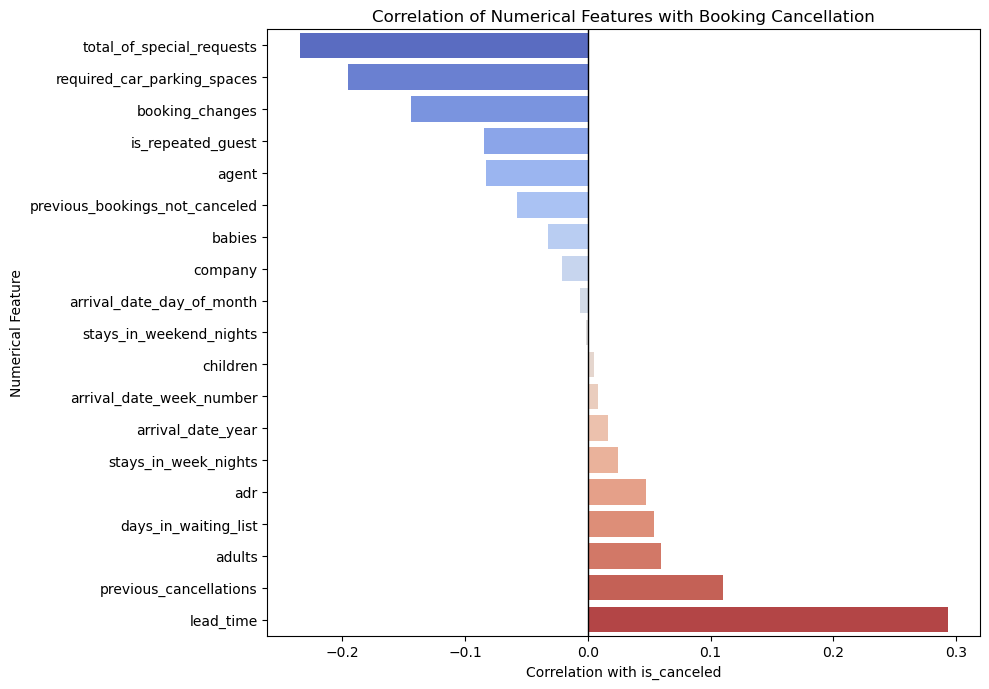

In [48]:
plt.figure(figsize=(10, 7))

target_corr_sorted = (
    correlation_matrix["is_canceled"]
    .drop("is_canceled")
    .sort_values()
)

sns.barplot(
    x=target_corr_sorted.values,
    y=target_corr_sorted.index,
    hue=target_corr_sorted.index,
    palette="coolwarm",
    legend=False
)

plt.title("Correlation of Numerical Features with Booking Cancellation")
plt.xlabel("Correlation with is_canceled")
plt.ylabel("Numerical Feature")

plt.axvline(
    x=0,
    color="black",
    linewidth=1
)

plt.tight_layout()
plt.show()

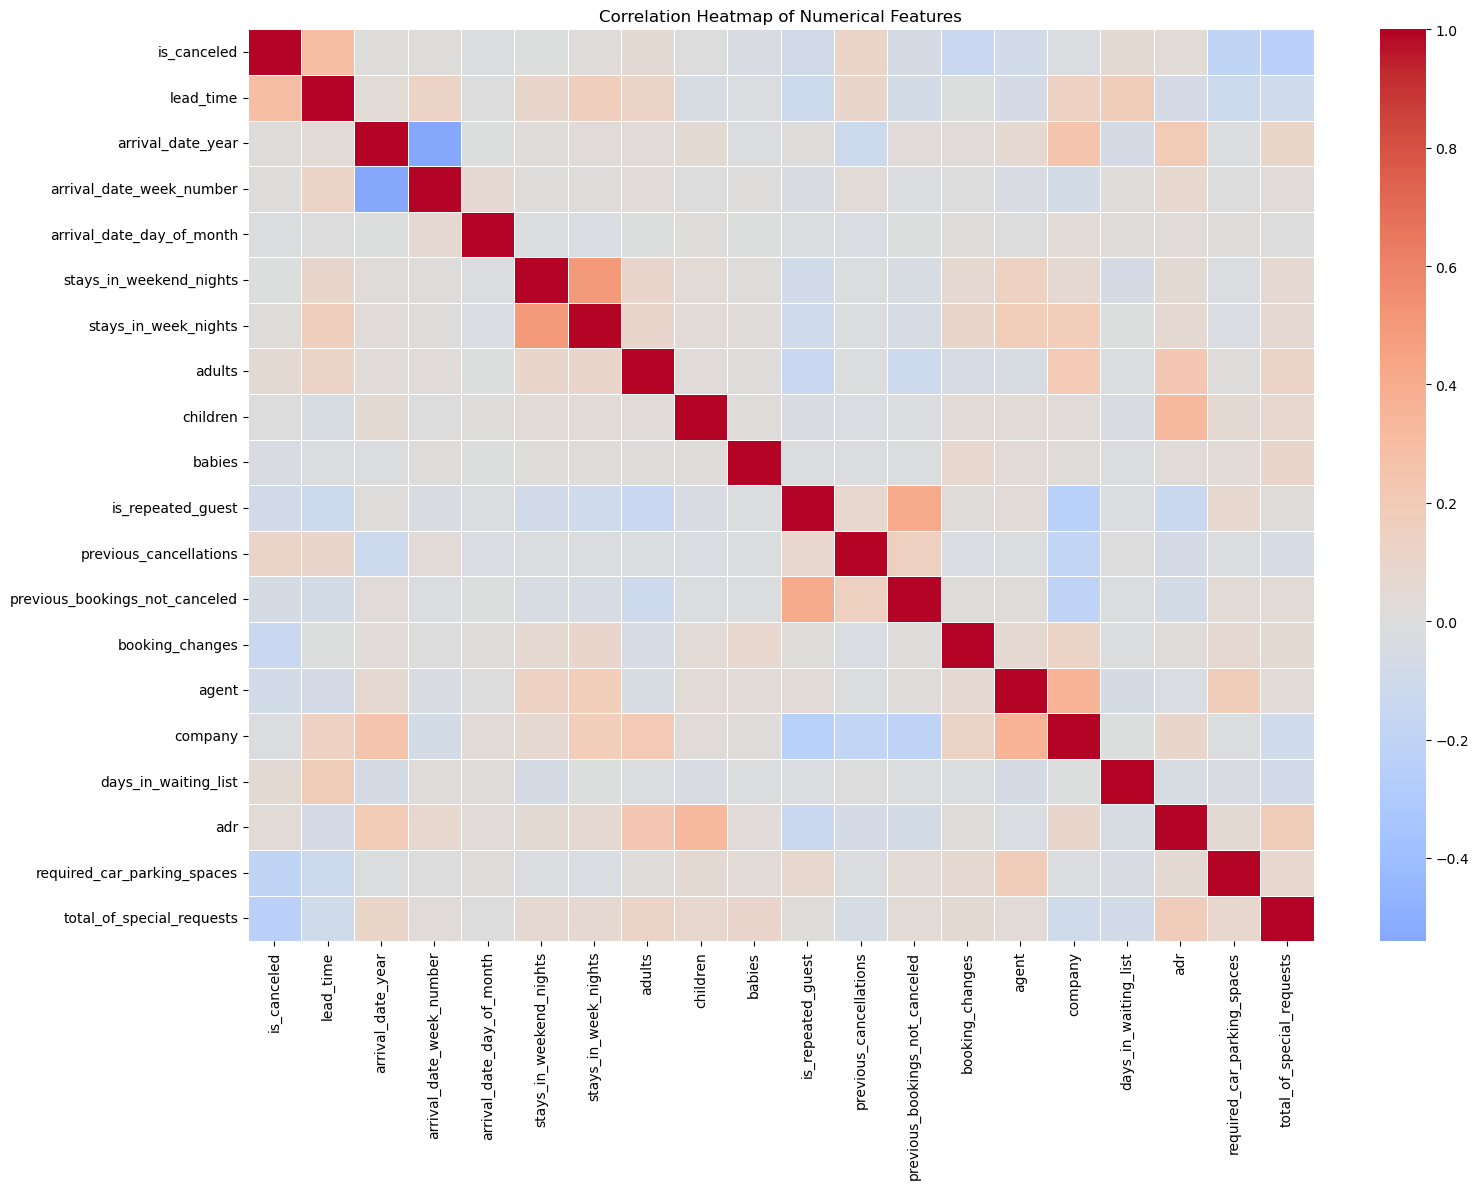

In [49]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.show()

In [50]:
print("Top Positive Correlations with is_canceled:")
print(
    target_correlations
    .head(5)
    .round(3)
)

print("\nTop Negative Correlations with is_canceled:")
print(
    target_correlations
    .tail(5)
    .sort_values()
    .round(3)
)

Top Positive Correlations with is_canceled:
lead_time                 0.293
previous_cancellations    0.110
adults                    0.060
days_in_waiting_list      0.054
adr                       0.048
Name: is_canceled, dtype: float64

Top Negative Correlations with is_canceled:
total_of_special_requests     -0.235
required_car_parking_spaces   -0.195
booking_changes               -0.144
is_repeated_guest             -0.085
agent                         -0.083
Name: is_canceled, dtype: float64


#### Observation

The numerical correlation analysis reveals several noteworthy linear relationships between the numerical features and the target variable `is_canceled`.

- `lead_time` shows the strongest positive linear correlation with booking cancellation, with a correlation coefficient of **0.293**. This is consistent with the earlier lead-time analysis, where bookings made further in advance generally showed higher cancellation rates.
- `previous_cancellations` has the second-highest positive correlation with the target at **0.110**, suggesting that previous cancellation history may provide useful predictive information.
- Other positive correlations with the target are relatively weak, including `adults` (**0.060**), `days_in_waiting_list` (**0.054**), and `adr` (**0.048**).

Several numerical features show negative correlations with booking cancellation:

- `total_of_special_requests` shows the strongest negative correlation with the target at **-0.235**. This supports the earlier analysis where bookings with special requests generally demonstrated lower cancellation rates.
- `required_car_parking_spaces` has a correlation of **-0.195**.
- `booking_changes` has a correlation of **-0.144**.
- `is_repeated_guest` and `agent` show weaker negative correlations of approximately **-0.085** and **-0.083**, respectively.

The correlation heatmap also reveals relationships among some predictor variables. For example, `arrival_date_year` and `arrival_date_week_number` show a noticeable negative relationship, while `stays_in_weekend_nights` and `stays_in_week_nights` show a positive relationship. Such relationships may require further consideration during feature selection and model development.

Overall, no numerical feature demonstrates an extremely strong linear correlation with the target variable. However, `lead_time`, `total_of_special_requests`, `required_car_parking_spaces`, `booking_changes`, and `previous_cancellations` show comparatively stronger linear associations than the other numerical variables.

These correlation results will not be used alone to remove or select features. Pearson correlation primarily captures linear relationships, while some features may contain non-linear predictive patterns that can be identified by machine learning algorithms. Furthermore, categorical variables such as `deposit_type`, `market_segment`, and `hotel` are not represented in this numerical correlation analysis and will be considered separately during model development.

### 1.19 Potential Data Leakage Identification

Data leakage occurs when information that would not realistically be available at the time of prediction is included as an input to the machine learning model. This can result in unrealistically high model performance and poor generalization to new bookings.

Since the objective of this project is to predict whether a hotel booking will be cancelled before its final outcome is known, features that directly or indirectly reveal the final reservation outcome must be carefully investigated.

The variables `reservation_status` and `reservation_status_date` are therefore examined as potential sources of target leakage.

In [51]:
df["reservation_status"].value_counts()

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

In [52]:
reservation_status_percentage = (
    df["reservation_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

reservation_status_percentage

reservation_status
Check-Out    62.96
Canceled     36.03
No-Show       1.01
Name: proportion, dtype: float64

In [53]:
status_target_table = pd.crosstab(
    df["reservation_status"],
    df["is_canceled"]
)

status_target_table

is_canceled,0,1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207


In [54]:
status_target_percentage = pd.crosstab(
    df["reservation_status"],
    df["is_canceled"],
    normalize="index"
).mul(100)

status_target_percentage.columns = [
    "Not Cancelled (%)",
    "Cancelled (%)"
]

status_target_percentage.round(2)

,Not Cancelled (%),Cancelled (%)
reservation_status,,
Canceled,0.0,100.0
Check-Out,100.0,0.0
No-Show,0.0,100.0


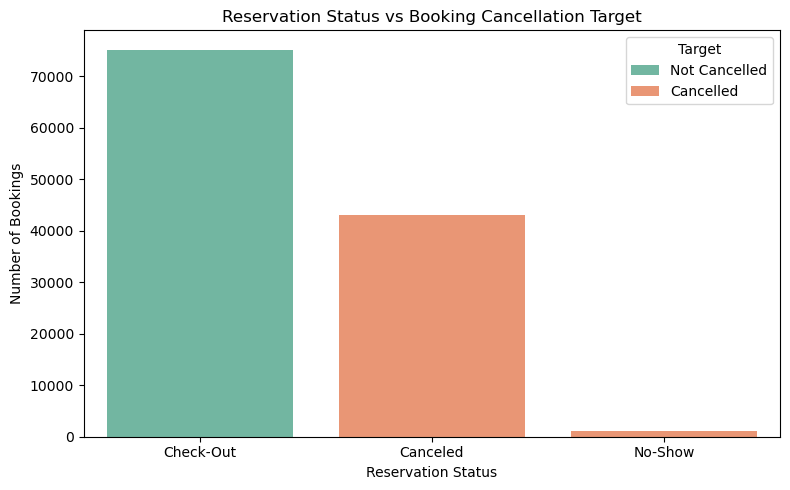

In [55]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="reservation_status",
    hue="is_canceled",
    palette="Set2"
)

plt.title("Reservation Status vs Booking Cancellation Target")
plt.xlabel("Reservation Status")
plt.ylabel("Number of Bookings")

plt.legend(
    title="Target",
    labels=["Not Cancelled", "Cancelled"]
)

plt.tight_layout()
plt.show()

In [56]:
df["reservation_status_date"].head(10)


0    2015-07-01
1    2015-07-01
2    2015-07-02
3    2015-07-02
4    2015-07-03
5    2015-07-03
6    2015-07-03
7    2015-07-03
8    2015-05-06
9    2015-04-22
Name: reservation_status_date, dtype: object

In [57]:
df["reservation_status_date"].dtype

dtype('O')

In [58]:
status_date = pd.to_datetime(
    df["reservation_status_date"],
    errors="coerce"
)

status_date.describe()

count                           119390
mean     2016-07-30 00:24:47.883407104
min                2014-10-17 00:00:00
25%                2016-02-01 00:00:00
50%                2016-08-07 00:00:00
75%                2017-02-08 00:00:00
max                2017-09-14 00:00:00
Name: reservation_status_date, dtype: object

#### Observation and Leakage Assessment

The analysis provides strong evidence that `reservation_status` is a direct source of target leakage.

The cross-tabulation between `reservation_status` and the target variable `is_canceled` shows the following relationship:

- All **75,166 `Check-Out` bookings** correspond to `is_canceled = 0` (Not Cancelled).
- All **43,017 `Canceled` bookings** correspond to `is_canceled = 1` (Cancelled).
- All **1,207 `No-Show` bookings** also correspond to `is_canceled = 1` (Cancelled).

Therefore, each reservation status category directly reveals the value of the target variable. If `reservation_status` were included as a model input, the model would effectively receive information about the final booking outcome instead of learning to predict the outcome from information available before cancellation.

The `reservation_status_date` variable also represents information associated with the date on which the final reservation status was recorded. Since the proposed system is intended to predict cancellation risk before the final booking outcome is known, this information would not be appropriate as a prediction-time input.

Consequently, both `reservation_status` and `reservation_status_date` are identified as potential post-outcome information and should be excluded from the predictive feature set during preprocessing to prevent target leakage.

The original variables will remain unchanged in the raw dataset. Their exclusion will only be performed within the preprocessing and modelling pipeline.

### 1.20 Identification of Non-Predictive and Artificial Features

The dataset contains several customer identification-related attributes, including `name`, `email`, `phone-number`, and `credit_card`.

According to the dataset documentation, these four attributes were artificially created and added to the dataset and are not part of the original hotel booking information. Therefore, their potential predictive value and suitability for inclusion in the machine learning model need to be carefully evaluated.

This analysis examines the uniqueness and cardinality of these attributes to determine whether they provide meaningful and generalizable information for predicting booking cancellations.

In [59]:
artificial_features = [
    "name",
    "email",
    "phone-number",
    "credit_card"
]

df[artificial_features].head()


,name,email,phone-number,credit_card
0,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [60]:
artificial_feature_summary = pd.DataFrame({
    "Non-Null Count": df[artificial_features].count(),
    "Unique Values": df[artificial_features].nunique()
})

artificial_feature_summary["Uniqueness (%)"] = (
    artificial_feature_summary["Unique Values"]
    / len(df)
    * 100
).round(2)

artificial_feature_summary

,Non-Null Count,Unique Values,Uniqueness (%)
name,119390,81503,68.27
email,119390,115889,97.07
phone-number,119390,119390,100.00
credit_card,119390,9000,7.54


In [61]:
artificial_missing = pd.DataFrame({
    "Missing Values": df[artificial_features].isnull().sum(),
    "Missing (%)": (
        df[artificial_features].isnull().mean() * 100
    ).round(2)
})

artificial_missing

,Missing Values,Missing (%)
name,0,0.0
email,0,0.0
phone-number,0,0.0
credit_card,0,0.0


In [62]:
for column in artificial_features:
    print(
        f"{column}: "
        f"{df[column].nunique()} unique values"
    )

name: 81503 unique values
email: 115889 unique values
phone-number: 119390 unique values
credit_card: 9000 unique values


#### Observation and Feature Assessment

The analysis indicates that the identification-related attributes have high cardinality and are not appropriate as predictive inputs for the proposed hotel booking cancellation model.

- `name` contains **81,503 unique values**, representing approximately **68.27% uniqueness** across the 119,390 booking records.
- `email` contains **115,889 unique values**, representing approximately **97.07% uniqueness**.
- `phone-number` contains **119,390 unique values**, resulting in **100% uniqueness**, meaning that every booking record has a unique phone number in this dataset.
- `credit_card` contains **9,000 unique values**, representing approximately **7.54% uniqueness**.
- None of these four attributes contain missing values.

According to the dataset documentation, `name`, `email`, `phone-number`, and `credit_card` were artificially created and added to the dataset rather than being part of the original hotel booking information.

These attributes primarily represent identification-related information rather than meaningful booking behaviour. In particular, the extremely high cardinality of attributes such as `email` and `phone-number` means that they mostly identify individual or near-individual records rather than providing reusable patterns that are expected to generalize to future hotel bookings.

Including such attributes may introduce unnecessary complexity and high-cardinality noise without providing meaningful, generalizable information for cancellation prediction. Therefore, these four variables are recommended for exclusion from the predictive feature set during preprocessing.

The original attributes will remain unchanged in the raw dataset. Their exclusion will only be implemented within the preprocessing and modelling pipeline.

### 1.21 Key EDA Findings and Handover

The initial data understanding and exploratory data analysis identified several important patterns, potential predictive features, and data-related concerns that should guide the subsequent stages of the project.

#### Key Findings

1. **Target Variable Distribution**
   - The dataset contains 119,390 hotel booking records.
   - 75,166 bookings (62.96%) were not cancelled.
   - 44,224 bookings (37.04%) were cancelled.
   - The target variable therefore shows a moderate class imbalance, which should be considered during model evaluation.

2. **Hotel Type and Cancellation**
   - City Hotel bookings showed a cancellation rate of 41.73%.
   - Resort Hotel bookings showed a lower cancellation rate of 27.76%.
   - This indicates that hotel type is associated with different cancellation patterns and may provide useful predictive information.

3. **Lead Time and Cancellation**
   - Cancelled bookings had a substantially higher average lead time of 144.85 days compared with 79.98 days for non-cancelled bookings.
   - The cancellation rate increased across the analysed lead-time groups, from 9.63% for bookings made 0-7 days in advance to 67.66% for bookings made more than 365 days in advance.
   - Therefore, lead time appears to be a potentially informative predictor of cancellation behaviour.

4. **Deposit Type and Cancellation**
   - No Deposit was the dominant category, representing 87.65% of all bookings, with a cancellation rate of 28.38%.
   - Non Refund bookings showed an unusually high cancellation rate of 99.36%.
   - Refundable bookings showed a cancellation rate of 22.22%, although this category contained only 162 records.
   - The unusual behaviour of the Non Refund category should be investigated further rather than interpreted causally.

5. **Market Segment and Cancellation**
   - Online TA was the largest market segment, representing 47.30% of bookings, with a cancellation rate of 36.72%.
   - The Groups segment showed the highest meaningful cancellation rate among the major segments at 61.06%.
   - The Undefined segment showed a 100% cancellation rate but contained only two records, making the observed percentage unreliable for general interpretation.
   - Market segment therefore appears to contain potentially useful predictive information.

6. **Previous Cancellation Behaviour**
   - Customers with no previous cancellations had a current cancellation rate of 33.91%.
   - Customers with exactly one previous cancellation showed a substantially higher current cancellation rate of 94.43%.
   - However, the relationship was not strictly linear across higher previous-cancellation groups.
   - Groups with two or more previous cancellations contained relatively few observations and therefore require cautious interpretation.

7. **Special Requests and Cancellation**
   - Bookings with no special requests had the highest observed cancellation rate at 47.72%.
   - Bookings with one or more special requests generally showed substantially lower cancellation rates.
   - The observed cancellation rate generally decreased as the number of special requests increased.
   - This suggests that `total_of_special_requests` may contain useful predictive information.

8. **Arrival Month and Cancellation**
   - August recorded the highest booking volume with 13,877 bookings (11.62%).
   - June showed the highest cancellation rate at 41.46%.
   - January showed the lowest observed cancellation rate at 30.48%.
   - The month with the largest booking volume was therefore not the month with the 